# Conceptual Question #1

This problem involves the K-means clustering algorithm.

## Part (a): Prove Equation 12.18

For a cluster \(C_k\), let \(\bar{x}_{kj}\) denote the mean of feature \(j\) within the cluster.

Equation 12.18 is

$$
\frac{1}{|C_k|}
\sum_{i,i' \in C_k}
\sum_{j=1}^{p}
(x_{ij}-x_{i'j})^2
=
2
\sum_{i \in C_k}
\sum_{j=1}^{p}
(x_{ij}-\bar{x}_{kj})^2.
$$

For a single feature \(j\), the identity

$$
\sum_{i,i' \in C_k}
(x_{ij}-x_{i'j})^2
=
2|C_k|
\sum_{i \in C_k}
(x_{ij}-\bar{x}_{kj})^2
$$

is a standard result from variance decomposition. Dividing both sides by \(|C_k|\) gives

$$
\frac{1}{|C_k|}
\sum_{i,i' \in C_k}
(x_{ij}-x_{i'j})^2
=
2
\sum_{i \in C_k}
(x_{ij}-\bar{x}_{kj})^2.
$$

Summing over all \(p\) features yields Equation 12.18. Therefore, the average pairwise squared distance within a cluster equals twice the total squared distance from observations to the cluster mean.

## Part (b): Why K-means Decreases the Objective

The K-means objective function decreases at each iteration because the algorithm alternates between two steps that cannot increase the within-cluster sum of squares. First, each observation is assigned to the nearest cluster centroid, which reduces or maintains the total squared distance. Second, the centroid of each cluster is recomputed as the mean of the observations assigned to that cluster. Since the mean minimizes squared deviations, this step also reduces or maintains the objective function.

As a result, each iteration of K-means either decreases the objective function or leaves it unchanged. The algorithm stops when the cluster assignments no longer change, meaning it has reached a local optimum. Because the solution depends on the initial random cluster assignments, K-means is usually run multiple times with different starting values.

# Applied Question #9

## Hierarchical Clustering on the USArrests Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler

# USArrests dataset
usarrests = pd.DataFrame({
    "Murder": [13.2,10.0,8.1,8.8,9.0,7.9,3.3,5.9,15.4,17.4,5.3,2.6,10.4,7.2,2.2,6.0,9.7,15.4,2.1,11.3,4.4,12.1,2.7,16.1,9.0,6.0,4.3,12.2,2.1,7.4,11.4,11.1,13.0,0.8,7.3,6.6,4.9,6.3,3.4,14.4,3.8,13.2,12.7,3.2,2.2,8.5,4.0,5.7,2.6,6.8],
    "Assault": [236,263,294,190,276,204,110,238,335,211,46,120,249,113,56,115,109,249,83,300,149,255,72,259,178,109,102,252,57,159,285,254,337,45,120,151,159,106,174,279,86,188,201,120,48,156,145,81,53,161],
    "UrbanPop": [58,48,80,50,91,78,77,72,80,60,83,54,83,65,57,66,52,66,51,67,85,74,66,44,70,53,62,81,56,89,70,86,45,44,75,68,67,72,87,48,45,59,80,80,32,63,73,39,66,60],
    "Rape": [21.2,44.5,31.0,19.5,40.6,38.7,11.1,15.8,31.9,25.8,20.2,14.2,24.0,21.0,11.3,18.0,16.3,22.2,7.8,27.8,16.3,35.1,14.9,17.1,28.2,16.4,16.5,46.0,9.5,18.8,32.1,26.1,16.1,7.3,21.4,20.0,29.3,14.9,8.3,22.5,12.8,26.9,25.5,22.9,11.2,20.7,26.2,9.3,10.8,15.6]
}, index=[
    "Alabama","Alaska","Arizona","Arkansas","California","Colorado","Connecticut","Delaware","Florida","Georgia",
    "Hawaii","Idaho","Illinois","Indiana","Iowa","Kansas","Kentucky","Louisiana","Maine","Maryland",
    "Massachusetts","Michigan","Minnesota","Mississippi","Missouri","Montana","Nebraska","Nevada","New Hampshire","New Jersey",
    "New Mexico","New York","North Carolina","North Dakota","Ohio","Oklahoma","Oregon","Pennsylvania","Rhode Island","South Carolina",
    "South Dakota","Tennessee","Texas","Utah","Vermont","Virginia","Washington","West Virginia","Wisconsin","Wyoming"
])

display(usarrests.head())

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


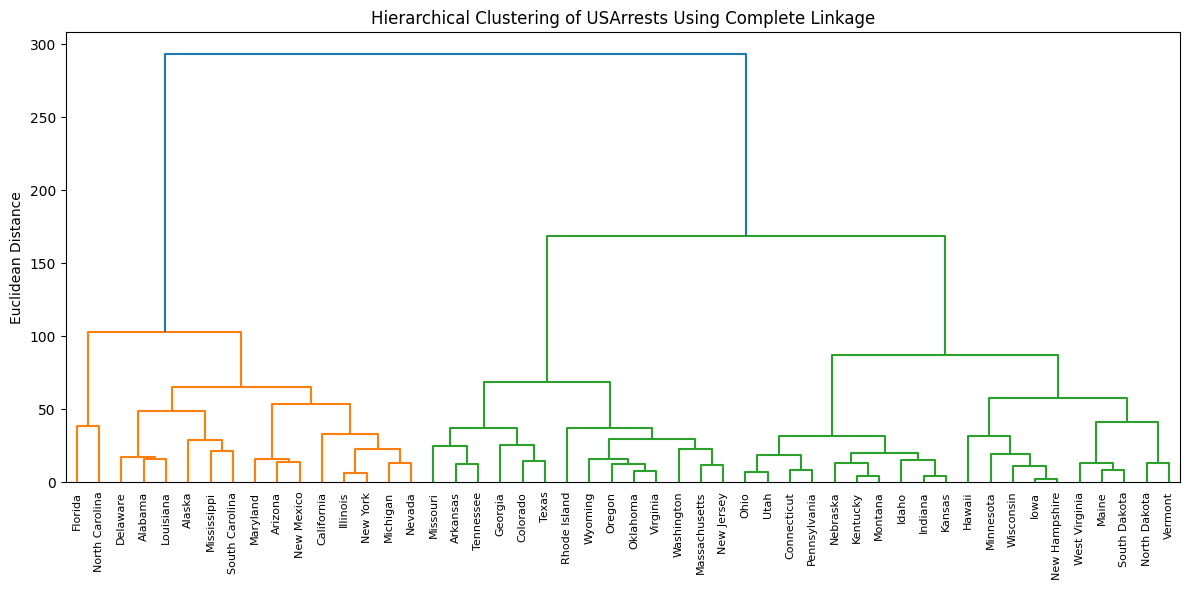

In [2]:
# Part (a): Hierarchical clustering with complete linkage and Euclidean distance
hc_complete = linkage(usarrests, method="complete", metric="euclidean")

plt.figure(figsize=(12, 6))
dendrogram(
    hc_complete,
    labels=usarrests.index.tolist(),
    leaf_rotation=90
)

plt.title("Hierarchical Clustering of USArrests Using Complete Linkage")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()

## Part (a): Dendrogram Interpretation

The dendrogram shows how states merge into clusters under complete linkage hierarchical clustering using Euclidean distance. States that merge at lower heights are more similar, while states that merge at higher heights are more dissimilar.

## Part (b): Three-Cluster Solution

The dendrogram was cut into three clusters using complete linkage hierarchical clustering. The resulting cluster memberships are shown below.

In [3]:
# Part (b): Cut dendrogram into 3 clusters

clusters = fcluster(hc_complete, 3, criterion='maxclust')

cluster_df = pd.DataFrame({
    'State': usarrests.index,
    'Cluster': clusters
})

for c in sorted(cluster_df['Cluster'].unique()):
    print(f"\nCluster {c}:")
    print(cluster_df[cluster_df['Cluster'] == c]['State'].tolist())


Cluster 1:
['Alabama', 'Alaska', 'Arizona', 'California', 'Delaware', 'Florida', 'Illinois', 'Louisiana', 'Maryland', 'Michigan', 'Mississippi', 'Nevada', 'New Mexico', 'New York', 'North Carolina', 'South Carolina']

Cluster 2:
['Arkansas', 'Colorado', 'Georgia', 'Massachusetts', 'Missouri', 'New Jersey', 'Oklahoma', 'Oregon', 'Rhode Island', 'Tennessee', 'Texas', 'Virginia', 'Washington', 'Wyoming']

Cluster 3:
['Connecticut', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Minnesota', 'Montana', 'Nebraska', 'New Hampshire', 'North Dakota', 'Ohio', 'Pennsylvania', 'South Dakota', 'Utah', 'Vermont', 'West Virginia', 'Wisconsin']


### Interpretation

Cluster 1 contains states with generally higher crime rates, particularly Assault and Murder rates.

Cluster 2 contains states with moderate crime levels.

Cluster 3 contains states with relatively lower crime rates and includes many rural states.

## Part (c): Hierarchical Clustering After Standardization

Because the variables are measured on different scales and have different variances, the data were standardized before performing hierarchical clustering again.

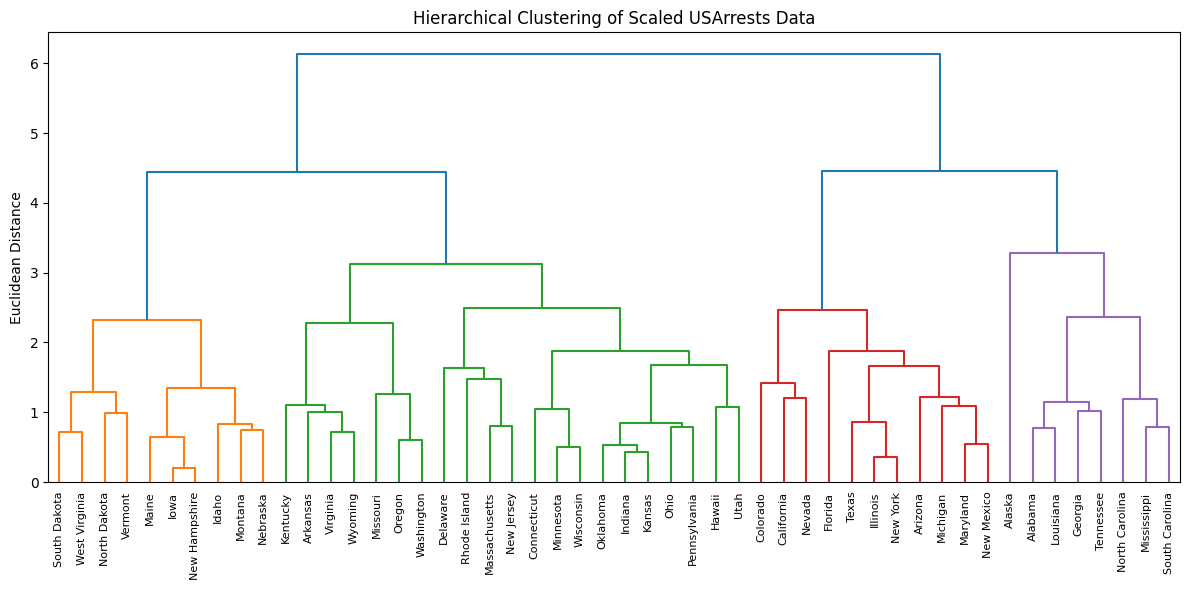

In [4]:
# Part (c): Hierarchical clustering after scaling

scaler = StandardScaler()
usarrests_scaled = scaler.fit_transform(usarrests)

hc_scaled = linkage(
    usarrests_scaled,
    method='complete',
    metric='euclidean'
)

plt.figure(figsize=(12,6))
dendrogram(
    hc_scaled,
    labels=usarrests.index.tolist(),
    leaf_rotation=90
)

plt.title("Hierarchical Clustering of Scaled USArrests Data")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()

### Effect of Scaling

After standardization, the clustering structure changes noticeably. In the original analysis, the Assault variable had the largest variance and therefore had a strong influence on the clustering results. Scaling places all variables on the same scale, allowing Murder, Assault, UrbanPop, and Rape to contribute equally to the distance calculations.

The resulting clusters are more balanced and reflect overall similarities among states rather than being driven by a single variable.

## Part (d): Comparison of the Two Dendrograms

The dendrograms obtained from the original and standardized data differ substantially. In the unscaled analysis, states are grouped primarily according to variables with larger variances, especially Assault. After standardization, each variable contributes equally to the clustering process, causing many states to be reassigned to different groups.

The standardized dendrogram is generally preferred because it prevents variables with large variances from dominating the clustering process and produces clusters that better represent overall similarities among states.

# Wine Data for Clustering

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [6]:
wine = pd.read_csv("wine-clustering.csv")

print(wine.shape)
display(wine.head())
print(wine.columns)

(178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline'],
      dtype='object')


## PCA Analysis

The variables are measured on different scales, so the data are standardized before performing Principal Components Analysis (PCA). PCA is used to reduce dimensionality while retaining at least 80% of the total variance in the dataset.

In [7]:
# Standardize data

scaler = StandardScaler()
wine_scaled = scaler.fit_transform(wine)

# PCA

pca = PCA()
pca.fit(wine_scaled)

# Explained variance

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Find number of components needed for 80% variance

n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

print("Number of components needed for 80% variance:", n_components_80)

# Display variance table

variance_df = pd.DataFrame({
    "Component": np.arange(1, len(explained_variance)+1),
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})

display(variance_df)

Number of components needed for 80% variance: 5


,Component,Explained Variance,Cumulative Variance
0,1,0.361988,0.361988
1,2,0.192075,0.554063
2,3,0.111236,0.665300
3,4,0.070690,0.735990
4,5,0.065633,0.801623
5,6,0.049358,0.850981
6,7,0.042387,0.893368
7,8,0.026807,0.920175
8,9,0.022222,0.942397
9,10,0.019300,0.961697


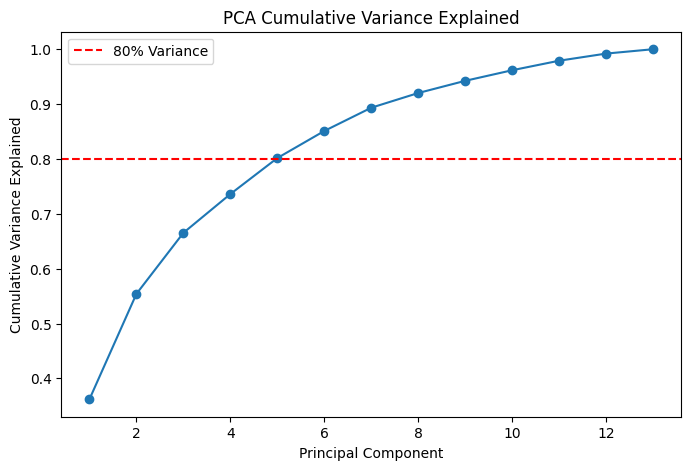

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    np.arange(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.80,
    color='red',
    linestyle='--',
    label='80% Variance'
)

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA Cumulative Variance Explained")
plt.legend()

plt.show()

In [9]:
pca_final = PCA(n_components=n_components_80)

wine_pca = pca_final.fit_transform(wine_scaled)

print("Reduced dataset shape:", wine_pca.shape)

Reduced dataset shape: (178, 5)


## PCA Results and Interpretation

The cumulative variance plot shows that the first five principal components explain approximately 80.2% of the total variance in the Wine dataset. Therefore, the original 13 variables were reduced to 5 principal components while retaining most of the information contained in the data.

This dimensionality reduction helps remove redundancy caused by correlated variables and simplifies subsequent clustering analyses.

## K-Means Clustering

K-means clustering was performed on the PCA-transformed dataset. Multiple values of k were evaluated using the elbow method to determine an appropriate number of clusters.

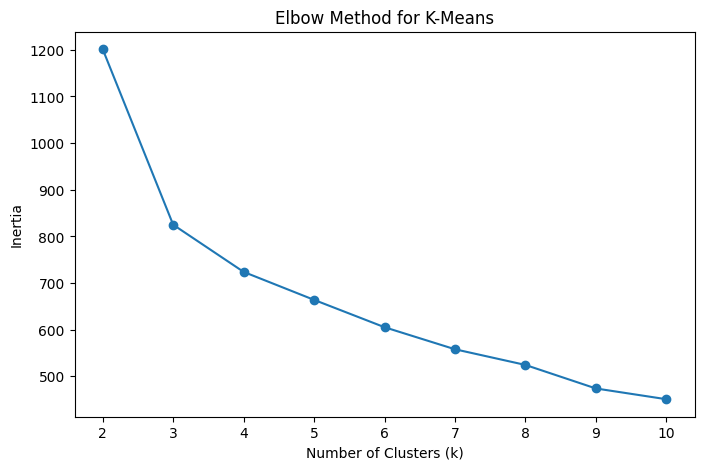

In [10]:
# Evaluate different k values

inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(wine_pca)
    inertia.append(kmeans.inertia_)

# Elbow plot

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")

plt.show()

In [11]:
# K-Means with k=3

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(wine_pca)

print("Cluster sizes:")
print(pd.Series(clusters).value_counts().sort_index())

Cluster sizes:
0    65
1    51
2    62
Name: count, dtype: int64


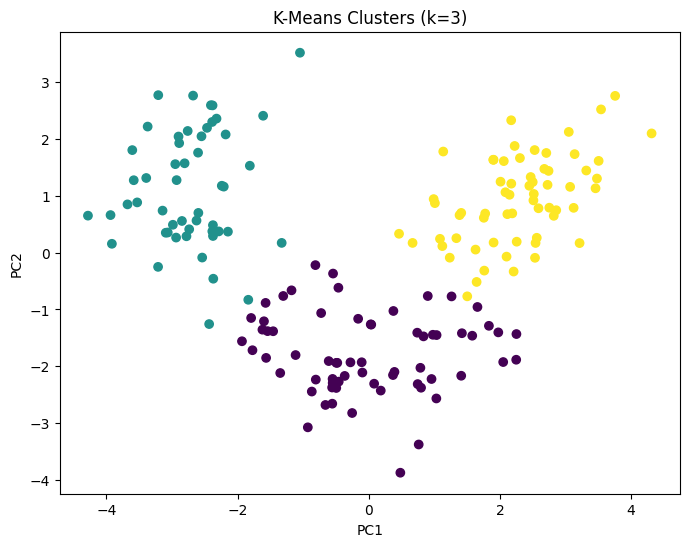

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    wine_pca[:,0],
    wine_pca[:,1],
    c=clusters
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (k=3)")

plt.show()

## K-Means Interpretation

The elbow plot was used to evaluate several values of k. The curve begins to flatten around k = 3, suggesting that three clusters provide a reasonable balance between model complexity and within-cluster variation.

Using k = 3, the observations separate into three distinct groups in the principal component space. These clusters likely represent wines with similar chemical compositions.

### K-Means Results

The elbow plot suggests that k = 3 is an appropriate choice because the decrease in inertia becomes less substantial after three clusters.

The final k-means solution produced clusters containing 65, 51, and 62 observations respectively. The scatter plot of the first two principal components shows clear separation among the three clusters, indicating that the wines can be grouped into distinct categories based on their chemical characteristics.

# Hierarchical Clustering

Hierarchical clustering was performed on the PCA-transformed data using complete linkage and Euclidean distance. The resulting dendrogram provides a visual representation of how observations merge into clusters.

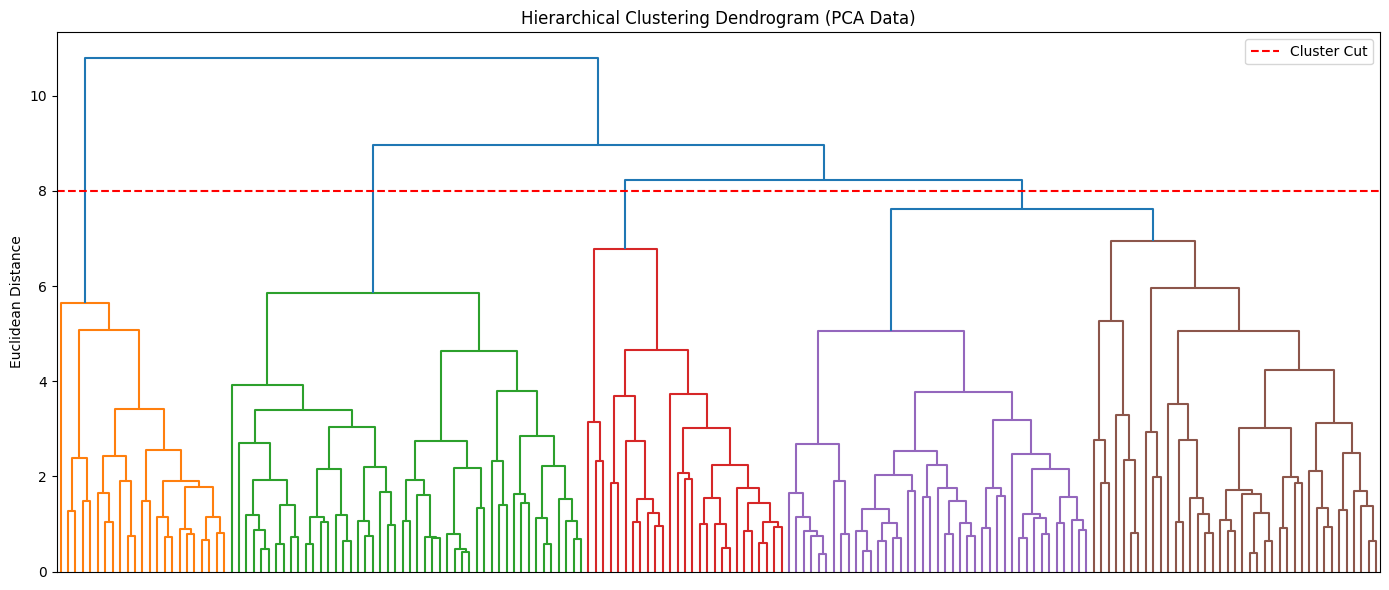

In [16]:
# Hierarchical clustering on PCA data

hc = linkage(
    wine_pca,
    method='complete',
    metric='euclidean'
)

plt.figure(figsize=(14, 6))

dendrogram(
    hc,
    no_labels=True,
    color_threshold=None
)

plt.axhline(y=8, color='red', linestyle='--', label='Cluster Cut')
plt.legend()

plt.title("Hierarchical Clustering Dendrogram (PCA Data)")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()

The dendrogram illustrates the hierarchical relationships among the wine observations after PCA transformation. Each vertical merge represents the combination of clusters at a specific Euclidean distance. Observation labels were omitted to improve readability because the dataset contains 178 samples. The large jumps in linkage distance suggest the presence of several well-separated groups within the data, supporting the use of a three-cluster solution.

In [14]:
# Three-cluster solution

hc_clusters = fcluster(
    hc,
    3,
    criterion='maxclust'
)

print("Hierarchical cluster sizes:")
print(pd.Series(hc_clusters).value_counts().sort_index())

Hierarchical cluster sizes:
1     23
2     48
3    107
Name: count, dtype: int64


## Hierarchical Clustering Interpretation

The dendrogram shows how observations merge into larger groups as the distance threshold increases. Cutting the dendrogram into three clusters produces groups that are broadly consistent with the k-means solution.

Because PCA reduced the dimensionality while preserving over 80% of the variance, the hierarchical clustering results are less affected by noise and multicollinearity among the original variables.

# Assumptions and Considerations

## PCA
- Variables should be numeric.
- Variables should be standardized when measured on different scales.
- PCA assumes that important information is captured through variance.

## K-Means
- Clusters are approximately spherical.
- Cluster sizes are reasonably similar.
- Results may depend on the initial cluster centers.

## Hierarchical Clustering
- Sensitive to the choice of distance metric and linkage method.
- Once observations are merged, the decision cannot be reversed.
- No requirement to specify the number of clusters beforehand.

# Overall Findings

PCA reduced the 13 original wine variables to 5 principal components while retaining approximately 80% of the total variance. This reduced dimensionality helped minimize redundancy among correlated variables. The k-means analysis suggested that k = 3 provides a reasonable clustering solution based on the elbow method. The resulting clusters were relatively balanced in size and appeared well separated in the principal component space. Hierarchical clustering produced a similar grouping structure, supporting the results obtained from k-means. Together, these methods suggest that the wine observations naturally separate into approximately three distinct groups based on their chemical characteristics. Overall, PCA combined with clustering techniques provided an effective way to identify meaningful patterns in the wine dataset while reducing complexity.

PCA was used to reduce dimensionality while preserving the majority of the dataset variance. The elbow method and k-means clustering identified three meaningful groups within the wine data. Combining PCA with clustering techniques is a common workflow for exploratory analysis and pattern discovery in multivariate datasets.

# References

Abdulhafedh, A. (2021). Incorporating K-means, hierarchical clustering and PCA in customer segmentation. *Journal of City and Development, 3*(1), 12–30. https://doi.org/10.12691/jcd-3-1-3

Buscemi, S., Grosso, G., Vasto, S., Galvano, F., & Marventano, S. (2023). The application of clustering on principal components for nutritional epidemiology: A workflow combining PCA, hierarchical clustering, and K-means. *Nutrients, 15*(1), Article 195. https://doi.org/10.3390/nu15010195

Ding, C., & He, X. (2004). K-means clustering via principal component analysis. In *Proceedings of the Twenty-First International Conference on Machine Learning (ICML)* (pp. 29–36). ACM. https://doi.org/10.1145/1015330.1015408


# GitHub Repository

Repository URL: https://github.com/delois005/Assignment7